# Completeness Analysis and $1/\mathcal{V}_{\max}$ Weights

## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("../").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.style import setup_style
from src.statistics import compute_vmax_weights
from src.plotting import plot_magnitude_completeness

setup_style(fontsize=12)

In [3]:
# Paths
ROOT = Path("../")
OUT_ALL = ROOT / "data" / "processed" / "gcs-allstars-complete.csv"
OUT_F = ROOT / "data" / "processed" / "gcs-Fstars-complete.csv"
OUT_G = ROOT / "data" / "processed" / "gcs-Gstars-complete.csv"
FIG_DIR = ROOT / "figures"

In [4]:
COLORS = {
    "F": "#2166ac",
    "G": "#d68d4d",
    "ALL": "#404040",
}

## 2. Load cleaned catalogue

In [5]:
df_F_raw = pd.read_csv(ROOT / "data" / "processed" / "gcs-Fstars.csv")
df_G_raw = pd.read_csv(ROOT / "data" / "processed" / "gcs-Gstars.csv")

print(f"Raw F-type stars: {len(df_F_raw):,}")
print(f"Raw G-type stars: {len(df_G_raw):,}")

Raw F-type stars: 3,450
Raw G-type stars: 2,564


## 3. Magnitude completeness

Under a homogeneous spatial distribution the differential count should follow 
$$
\dfrac{d\log N}{dm} = 0.6. \qquad \text{(Euclidean slope)}
$$
The turnover point of each population defines the completeness limit.

Inferred completeness limits: F = 7.72 mag | G = 8.29 mag


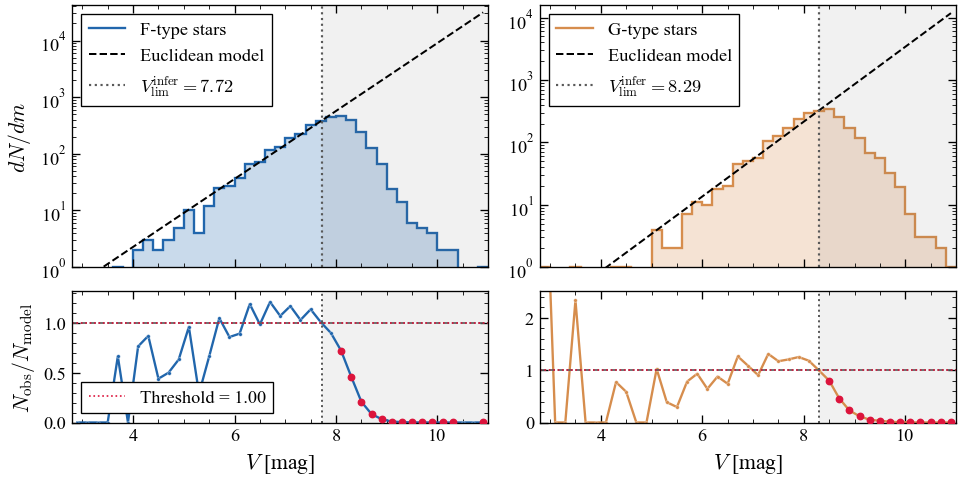

In [6]:
fig, axes, V_LIM = plot_magnitude_completeness(
    df_F_raw,
    df_G_raw,
    completeness_threshold=1.0,
    interpolate_vlim=True,
    figsize=(8, 4),
)
print(
    f"Inferred completeness limits: F = {V_LIM['F']:.2f} mag | G = {V_LIM['G']:.2f} mag"
)
fig.savefig(FIG_DIR / "fig_magnitude_completeness.pdf")
plt.show()

## 4. Apply magnitude cuts

In [7]:
df_F = df_F_raw[df_F_raw["Vmag"] <= V_LIM["F"]].copy()
df_G = df_G_raw[df_G_raw["Vmag"] <= V_LIM["G"]].copy()

df_F["SpecType"] = "F"
df_G["SpecType"] = "G"

print(f"Volume-limited F-type: {len(df_F):,}")
print(f"Volume-limited G-type: {len(df_G):,}")

Volume-limited F-type: 1,475
Volume-limited G-type: 1,298


## 5. Derived columns

### 5a. Effective temperature

In [8]:
for df in [df_F, df_G]:
    df["Teff"] = 10.0 ** df["logTe"]

### 5b. Projected Galactic-plane distance

$$
R_{xy} = \sqrt{X^2 + Y^2}
$$

In [9]:
for df in [df_F, df_G]:
    df["R_xy"] = np.sqrt(df["X"] ** 2 + df["Y"] ** 2)

### 5c. $1/\mathcal{V}_{\max}$ weights

For each star, $\mathcal{V}_{\max}$ is the volume within which it could be detected given the survey's apparent-magnitude limit:

$$
r_{\max} = 10^{(V_{\lim} - M + 5)/5}, \qquad
V_{\max} = \frac{4\pi}{3}\,r_{\max}^3, \qquad
w_i = \frac{1}{V_{\max}}
$$

In [10]:
df_F["w_vmax"] = compute_vmax_weights(
    df_F, V_LIM, type_col="SpecType", abs_mag_col="VMAG"
)
df_G["w_vmax"] = compute_vmax_weights(
    df_G, V_LIM, type_col="SpecType", abs_mag_col="VMAG"
)

print(f"w_vmax range F: {df_F['w_vmax'].min():.3e} - {df_F['w_vmax'].max():.3e}")
print(f"w_vmax range G: {df_G['w_vmax'].min():.3e} - {df_G['w_vmax'].max():.3e}")

w_vmax range F: 1.332e-08 - 4.059e-06
w_vmax range G: 1.588e-08 - 1.442e-05


In [11]:
(1.442e-05) / (1.332e-08)

1082.5825825825825

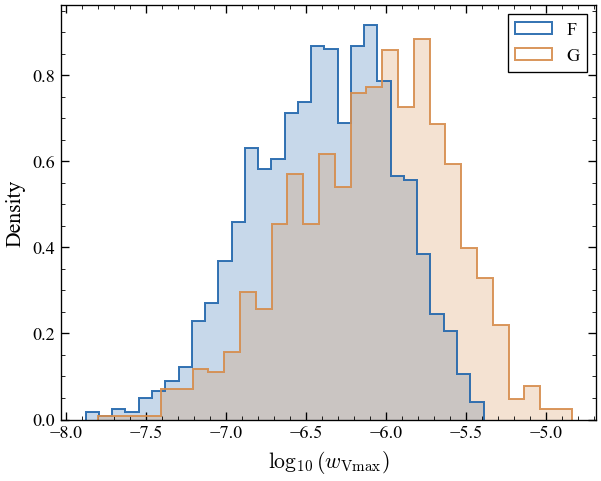

In [12]:
fig, ax = plt.subplots(figsize=(5, 4))

ax.hist(
    np.log10(df_F["w_vmax"]),
    bins=30,
    color=COLORS["F"],
    histtype="stepfilled",
    alpha=0.25,
    lw=0,
    density=True,
)
ax.hist(
    np.log10(df_F["w_vmax"]),
    bins=30,
    color=COLORS["F"],
    histtype="step",
    alpha=0.9,
    lw=1.2,
    ls="-",
    label="F",
    density=True,
)
ax.hist(
    np.log10(df_G["w_vmax"]),
    bins=30,
    color=COLORS["G"],
    histtype="stepfilled",
    alpha=0.25,
    lw=0,
    density=True,
)
ax.hist(
    np.log10(df_G["w_vmax"]),
    bins=30,
    color=COLORS["G"],
    histtype="step",
    alpha=0.9,
    lw=1.2,
    ls="-",
    label="G",
    density=True,
)

ax.set_xlabel(r"$\log_{10}(w_{\rm Vmax})$")
ax.set_ylabel("Density")
ax.legend()
plt.show()

## 6. Save enriched catalogues

In [13]:
df_all = pd.concat([df_F, df_G], ignore_index=True)

df_all.to_csv(OUT_ALL, index=False)
df_F.to_csv(OUT_F, index=False)
df_G.to_csv(OUT_G, index=False)

print(f"Saved {len(df_all):,} stars ({OUT_ALL.name})")
print(f"  F-type : {len(df_F):,} ({OUT_F.name})")
print(f"  G-type : {len(df_G):,} ({OUT_G.name})")

Saved 2,773 stars (gcs-allstars-complete.csv)
  F-type : 1,475 (gcs-Fstars-complete.csv)
  G-type : 1,298 (gcs-Gstars-complete.csv)


In [14]:
df_all[
    ["Name", "SpecType", "Vmag", "Dist", "Teff", "vsini", "R_xy", "w_vmax"]
].describe()

,Vmag,Dist,Teff,vsini,R_xy,w_vmax
count,2773.000000,2773.000000,2773.000000,2773.000000,2773.000000,2.773000e+03
mean,7.333378,61.197620,6063.916878,10.839885,48.977751,9.775238e-07
std,0.670241,27.248533,393.229845,14.567538,26.125092,1.195387e-06
min,2.806000,6.000000,4977.370850,1.000000,0.000002,1.331831e-08
25%,7.002000,42.000000,5780.960474,3.000000,30.515656,2.561233e-07
50%,7.456000,56.000000,6039.486294,6.000000,44.738963,6.011443e-07
75%,7.767000,76.000000,6338.697113,12.000000,63.261462,1.237226e-06
max,8.291000,228.000000,7362.070975,130.000000,227.444608,1.442045e-05
